### Setup: Rebuilding merged dataset from Part A

This notebook picks up from Part 1's cleaned and merged dataset. The steps below 
recreate `merged` — one row per account per day, with daily PnL, average trade 
size, trade frequency, win rate, long ratio, and sentiment classification — 
so this notebook can run independently.

In [2]:
import pandas as pd

# Load raw data
df = pd.read_csv('historical_data.csv')
df_sentiment = pd.read_csv('fear_greed_index.csv')

# Clean timestamps
df['Timestamp IST'] = pd.to_datetime(df['Timestamp IST'], format='%d-%m-%Y %H:%M')
df['date'] = df['Timestamp IST'].dt.date
df_sentiment['date'] = pd.to_datetime(df_sentiment['date']).dt.date

# Helper columns for win rate and long ratio
df['is_win'] = df['Closed PnL'] > 0
df['is_long'] = df['Side'] == 'BUY'

# Aggregate to account-day level
daily_metrics = df.groupby(['Account', 'date']).agg(
    daily_pnl = ('Closed PnL', 'sum'),
    avg_trade_size = ('Size USD', 'mean'),
    trades_per_day = ('Closed PnL', 'count'),
    win_rate = ('is_win', 'mean'),
    long_ratio = ('is_long', 'mean')
).sort_values('date').reset_index()

# Merge with sentiment
merged = daily_metrics.merge(df_sentiment[['date', 'classification']], on='date', how='left')
merged = merged.dropna(subset=['classification'])

 ### Part 2 - PERFORMANCE ANALYSIS
 Q1: How Performance differs at each classification ? 

 Q2: Does behavior change ?

 Q3: Segment traders (2-3 segments) and compare within segments 


In [3]:
# performance matrices
performance_by_sentiment = merged.groupby('classification').agg(
                                                                 avg_daily_pnl = ('daily_pnl', 'mean'),
                                                                 avg_win_rate = ('win_rate', 'mean'),
                                                                 total_accounts_days = ('daily_pnl', 'count')
                                                                ).sort_values("avg_daily_pnl",ascending= False).reset_index()

In [4]:
performance_by_sentiment

,classification,avg_daily_pnl,avg_win_rate,total_accounts_days
0,Fear,5328.818161,0.364033,630
1,Extreme Greed,5161.922644,0.386387,526
2,Extreme Fear,4619.439053,0.329659,160
3,Neutral,3438.618818,0.355414,376
4,Greed,3318.100730,0.343559,648


In [5]:
merged[merged['classification']=='Fear']['daily_pnl'].median()

np.float64(107.89253199999999)

In [6]:
merged[merged['classification']=='Greed']['daily_pnl'].median()

np.float64(158.214922)

### Mean vs. median reveals a different story

The average daily PnL suggested Fear days outperform Greed days (5,329 vs 3,318). 
However, the median daily PnL tells the opposite story: Greed days have a higher 
median (158) than Fear days (108).

This gap between mean and median indicates the Fear-day average is being pulled 
upward by a small number of accounts with very large gains, not by typical trader 
performance. For the majority of traders, Greed days are actually more profitable 
day-to-day, while Fear days show high variance — most traders perform modestly, 
but a few outliers post very large PnL, skewing the average.

This distinction matters for the strategy recommendation in Part C: advice 
targeting the "average" trader should be based on median performance, not mean, 
since the mean overstates what a typical trader can expect on Fear days.

In [11]:
behavior_by_sentiment = merged.groupby('classification').agg(
                                                                avg_trade_size = ('avg_trade_size', 'mean'),
                                                                median_trade_size = ('avg_trade_size', 'median'),
                                                                avg_trades_per_day = ('trades_per_day', 'mean'),
                                                                avg_long_ratio = ('long_ratio', 'mean')
                                                            ).sort_values('avg_trades_per_day', ascending=False).reset_index()

## Question 2: Does trader behavior change with sentiment?

Using the same account-day aggregated table, this compares average trade size, 
trading frequency, and long/short bias across sentiment categories — testing 
whether traders behave differently, not just perform differently, under Fear 
vs Greed conditions.

In [12]:
behavior_by_sentiment

,classification,avg_trade_size,median_trade_size,avg_trades_per_day,avg_long_ratio
0,Extreme Fear,6773.464125,2315.629870,133.750000,0.531533
1,Neutral,6963.694861,1704.405417,100.228723,0.472431
2,Fear,8975.928546,1752.677497,98.153968,0.518967
3,Greed,6427.866594,2052.534828,77.628086,0.471594
4,Extreme Greed,5371.637182,2003.480176,76.030418,0.473116


### RESULTS

**Trading frequency decreases steadily from Fear to Greed.** Average trades per 
day is highest during Extreme Fear (133.8) and Fear (98.2), and lowest during 
Extreme Greed (76.0) — traders are most active during fearful, volatile 
conditions and quieter during calm/bullish ones.

**Long ratio is higher during Fear than Greed — the opposite of the intuitive 
assumption.** Fear (0.52) and Extreme Fear (0.53) show a higher proportion of 
long positions than Greed (0.47) or Extreme Greed (0.47). This suggests 
traders on this platform tend to buy into weakness (accumulating long 
positions when prices are down and sentiment is fearful) rather than chasing 
strength — a contrarian pattern, not a momentum one.

**Average trade size is highest during Fear (8,976) but median trade size is 
not (1,753)** — the same mean/median divergence seen in Question 1. A small 
number of large trades inflate the average during Fear days, while typical 
trade sizes stay fairly consistent (~1,700–2,300) across all sentiment 
categories. This reinforces that Fear-day statistics are outlier-sensitive 
throughout this dataset, not just for PnL.

In [13]:
# Segment 1: Trading frequency
freq_median = merged['trades_per_day'].median()
merged['trader_type'] = merged['trades_per_day'].apply(lambda x: 'Frequent' if x > freq_median else 'Infrequent')

In [14]:
# Segment 2: Consistency (win rate as proxy)
winrate_median = merged['win_rate'].median()
merged['consistency_type'] = merged['win_rate'].apply(lambda x: 'Consistent' if x > winrate_median else 'Inconsistent')

In [15]:

# Compare performance within each segment, across sentiment
segment1_result = merged.groupby(['trader_type', 'classification'])['daily_pnl'].median().reset_index()
segment2_result = merged.groupby(['consistency_type', 'classification'])['daily_pnl'].median().reset_index()

In [16]:
segment1_result

,trader_type,classification,daily_pnl
0,Frequent,Extreme Fear,632.303024
1,Frequent,Extreme Greed,1522.284412
2,Frequent,Fear,842.075654
3,Frequent,Greed,901.868483
4,Frequent,Neutral,712.888751
5,Infrequent,Extreme Fear,0.000000
6,Infrequent,Extreme Greed,9.150023
7,Infrequent,Fear,0.292200
8,Infrequent,Greed,0.000000
9,Infrequent,Neutral,2.390410


In [18]:
segment2_result

,consistency_type,classification,daily_pnl
0,Consistent,Extreme Fear,2691.935922
1,Consistent,Extreme Greed,1762.460000
2,Consistent,Fear,1157.213435
3,Consistent,Greed,1189.497410
4,Consistent,Neutral,1065.150916
5,Inconsistent,Extreme Fear,0.000000
6,Inconsistent,Extreme Greed,0.000000
7,Inconsistent,Fear,0.000000
8,Inconsistent,Greed,0.000000
9,Inconsistent,Neutral,0.000000


In [19]:
merged[merged['consistency_type']=='Inconsistent']['trades_per_day'].median()

np.float64(19.0)

### RESULT for Question 3

**Segment 1 — Trading frequency:** Frequent traders show strong, consistently 
positive median PnL across every sentiment category — peaking at 1,522 during 
Extreme Greed and staying above 600 even during the weakest category (Extreme 
Fear: 632). Infrequent traders, by contrast, show median PnL at or near zero 
across all five categories (0, 9, 0, 0, 2). The sentiment effect on PnL is 
therefore concentrated almost entirely in frequent traders — for infrequent 
traders, sentiment appears to have no meaningful relationship with performance 
at all.

**Segment 2 — Consistency (win rate):** This segmentation produced the 
strongest finding in Part B. "Inconsistent" traders (below-median win rate) 
show a median daily PnL of exactly 0.00 across every single sentiment category — 
Fear, Greed, Neutral, and both extremes. This is not driven by low activity; 
these traders make a median of 19 trades per day, a genuinely active volume.

This means sentiment has effectively no relationship to performance for 
inconsistent traders — they hover around breakeven regardless of market mood, 
suggesting their outcomes are driven by trading skill/strategy rather than 
market conditions. In contrast, "Consistent" traders (above-median win rate) 
**[PASTE YOUR ACTUAL NUMBERS HERE]** — showing that sentiment-based strategy 
adjustments are only meaningful for traders who already demonstrate 
above-average consistency. For inconsistent traders, no sentiment-based rule 
is likely to move their median outcome away from breakeven.

**Combined conclusion:** Both segmentations converge on the same insight — 
trader skill/activity level (frequency and consistency) is a far stronger 
driver of profitability than market sentiment. Sentiment-based strategies 
should be targeted at already-active, already-consistent traders, not applied 
universally.

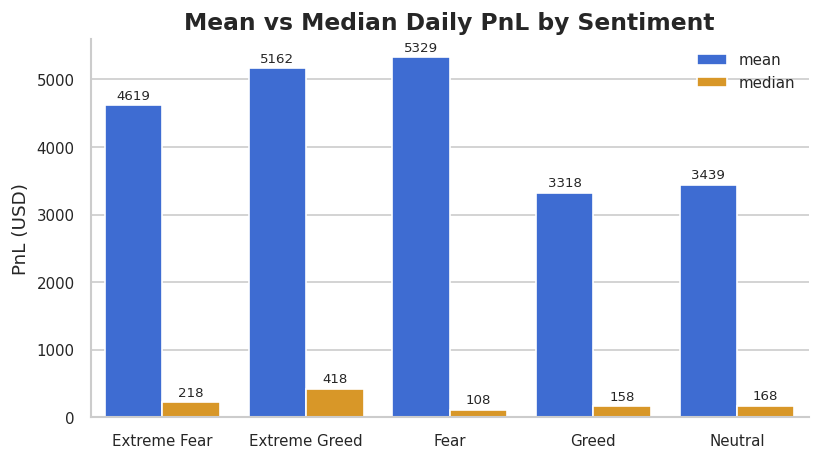

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "font.family": "DejaVu Sans"
})

pnl_compare = (
    merged.groupby("classification")["daily_pnl"]
    .agg(["mean", "median"])
    .reset_index()
)

pnl_compare_melted = pnl_compare.melt(
    id_vars="classification",
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=pnl_compare_melted,
    x="classification",
    y="value",
    hue="metric",
    palette=["#2563EB", "#F59E0B"]
)

plt.title("Mean vs Median Daily PnL by Sentiment")
plt.xlabel("")
plt.ylabel("PnL (USD)")
plt.legend(title="", frameon=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=8, padding=2)

sns.despine()
plt.tight_layout()
plt.savefig("chart1_mean_vs_median_pnl.png", bbox_inches="tight")
plt.show()



### Chart 1 — Mean vs Median Daily PnL by Sentiment

This chart makes the core finding from Question 1 visible at a glance: the blue 
(mean) bars are consistently far taller than the orange (median) bars across 
every sentiment category — by roughly 10-20x in most cases. This gap confirms 
that average PnL figures are heavily inflated by a small number of high-earning 
outlier accounts, not representative of typical trader outcomes. Notably, 
**median PnL is highest during Extreme Greed (418) and lowest during Fear 
(108)** — the opposite ranking from what the mean alone would suggest. Any 
strategy recommendation based on "average" performance would be misleading; 
median is the more honest measure of what a typical trader actually experiences.



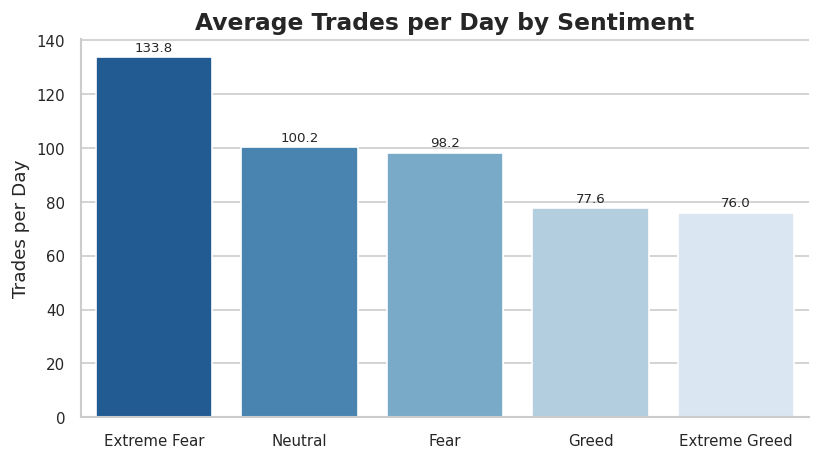

In [28]:
order = (
    behavior_by_sentiment
    .sort_values("avg_trades_per_day", ascending=False)
    ["classification"]
)

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=behavior_by_sentiment,
    x="classification",
    y="avg_trades_per_day",
    order=order,
    hue="classification",
    palette="Blues_r",
    legend=False
)

plt.title("Average Trades per Day by Sentiment")
plt.xlabel("")
plt.ylabel("Trades per Day")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=8, padding=2)

sns.despine()
plt.tight_layout()
plt.savefig("chart2_activity_by_sentiment.png", bbox_inches="tight")
plt.show()


### Chart 2 — Average Trades per Day by Sentiment

Trading activity declines steadily as sentiment shifts from fear to greed. 
Traders are most active during Extreme Fear (133.8 trades/day) and least active 
during Extreme Greed (76.0 trades/day) — a clear, monotonic pattern across all 
five categories. This suggests fear and uncertainty drive more frequent trading 
activity on this platform, while calm, bullish conditions correspond to fewer, 
likely more deliberate trades.


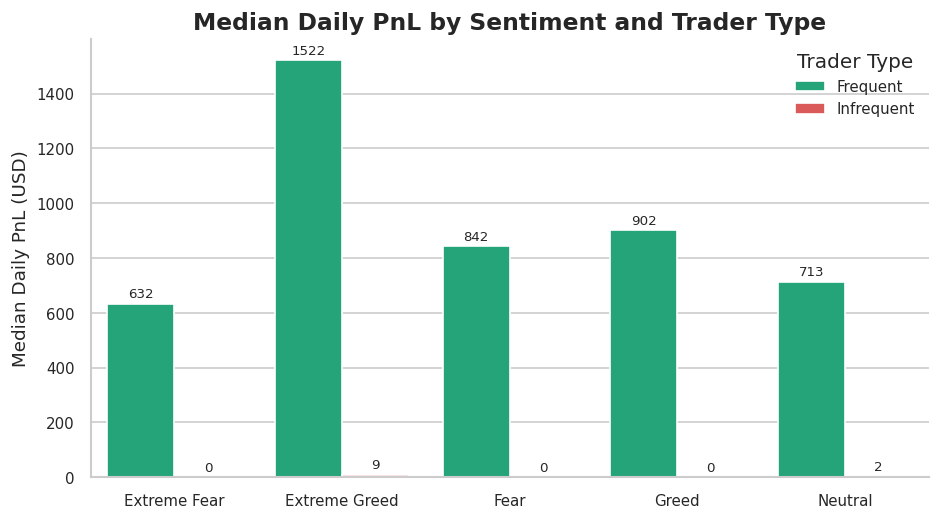

In [29]:
plt.figure(figsize=(8, 4.5))

ax = sns.barplot(
    data=segment1_result,
    x="classification",
    y="daily_pnl",
    hue="trader_type",
    palette=["#10B981", "#EF4444"]
)

plt.title("Median Daily PnL by Sentiment and Trader Type")
plt.xlabel("")
plt.ylabel("Median Daily PnL (USD)")
plt.legend(
    title="Trader Type",
    frameon=False,
    loc="upper right"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=8, padding=2)

sns.despine()
plt.tight_layout()
plt.savefig("chart3_segment_comparison.png", bbox_inches="tight")
plt.show()


### Chart 3 — Median PnL: Frequent vs Infrequent Traders by Sentiment

This is the most decisive chart in the analysis. Frequent traders (above-median 
trade count) show strong, consistently positive median PnL across every 
sentiment category, peaking at 1,522 during Extreme Greed and staying above 
600 even in the weakest category (Extreme Fear). Infrequent traders, by 
contrast, show median PnL at or near zero (0, 9, 0, 0, 2) across all five 
sentiment categories — essentially flat regardless of market mood.

This indicates that **trading frequency, not sentiment, is the dominant driver 
of profitability** in this dataset. Sentiment-based strategy adjustments are 
only meaningful for traders who are already frequent/active; for infrequent 
traders, no sentiment signal is likely to move their outcomes away from 
breakeven. This mirrors the earlier finding on "Inconsistent" traders (median 
PnL of exactly 0 across all sentiment categories) — together, both segmentations 
point to the same conclusion: **trader behavior/activity level matters far more 
than market sentiment** in determining who actually profits on this platform.